# 02 · Exploratory analysis

Before modeling exposure, look at what the field and the No. 44 actually did. The key variables for camera time are **average running position** (where the car spends the race, not just where it finishes) and **laps led**.

In [1]:
import sys, json
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / "src"))
import duckdb, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from viz import use_style, money_axis, headline, source, SEQ, FIELD, NY, THIRD, INK, INK_2, CONTEXT
import matplotlib
use_style()
pd.set_option("display.max_columns", 20, "display.width", 140)
ROOT = Path.cwd().parent
con = duckdb.connect(str(ROOT / "data" / "nascar_2025.duckdb"), read_only=True)
s = con.execute("SELECT * FROM starters").df()
s["charter"] = s.car_number.isin(con.execute("SELECT car_number FROM entries GROUP BY 1 HAVING count(*) = 36").df().car_number)
s["group"] = np.select([s.is_ny_racing, s.charter], ["No. 44", "Charter cars"], "Other open cars")

## The No. 44's 2025 season

In [2]:
ny = s[s.is_ny_racing].sort_values("race_date")
ny[["race_date", "track_name", "broadcaster", "driver", "sponsor", "start_ps", "avg_ps", "finish", "status", "top15_laps", "lead_laps"]].reset_index(drop=True)

,race_date,track_name,broadcaster,driver,sponsor,start_ps,avg_ps,finish,status,top15_laps,lead_laps
0,2025-02-23,Atlanta Motor Speedway,FOX,JJ Yeley,Green River Whiskey,39,35.43,37,Accident,2,0
1,2025-03-23,Homestead-Miami Speedway,FS1,JJ Yeley,PCNY,37,35.96,35,Running,0,0
2,2025-04-06,Darlington Raceway,FS1,JJ Yeley,Wawa,38,37.13,38,Brakes,1,0
3,2025-04-27,Talladega Superspeedway,FOX,JJ Yeley,Barnett Southern Corporation,39,30.01,32,Running,3,2
4,2025-05-25,Charlotte Motor Speedway,PRIME VIDEO,Derek Kraus,Western States Flooring,37,36.37,32,Running,0,0
5,2025-06-01,Nashville Superspeedway,PRIME VIDEO,JJ Yeley,Fanatics Sportsbook,38,35.21,34,Running,0,0
6,2025-06-22,Pocono Raceway,PRIME VIDEO,Brennan Poole,Members 1st Credit Union,37,34.01,34,Drivetrain,0,0
7,2025-07-20,Dover Motor Speedway,TNT,JJ Yeley,Ultimate Tailgating RV,37,34.00,34,Fatigue,2,0
8,2025-08-10,Watkins Glen International,USA,JJ Yeley,Syracuse Football NIL,38,34.54,38,Running,0,0
9,2025-08-23,Daytona International Speedway,NBC,Joey Gase,NFPA,40,30.58,28,Running,1,0


14 starts, four drivers, a different primary sponsor almost every week. The car never led a lap and ran inside the top 15 for 26 laps all season. Where does that put it relative to the field?

/var/folders/0f/9rvn96j94zsfhr8zsbzjx1700000gn/T/ipykernel_85728/3475362790.py:4: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  bp = ax.boxplot(data, vert=False, widths=0.55, patch_artist=True, medianprops=dict(color=INK, lw=1.5),


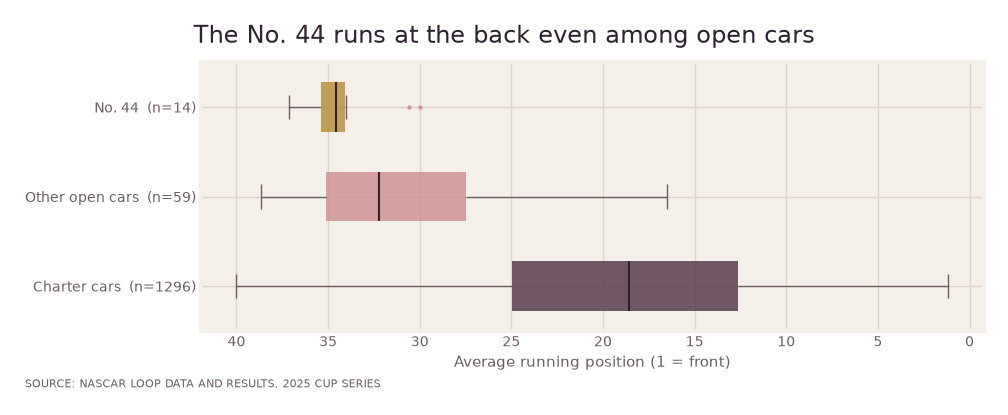

,count,25%,50%,75%
group,,,,
Charter cars,1296.0,12.7,18.6,25.0
No. 44,14.0,34.1,34.6,35.4
Other open cars,59.0,27.5,32.2,35.1


In [3]:
fig, ax = plt.subplots(figsize=(9, 3.4))
groups = ["Charter cars", "Other open cars", "No. 44"]
data = [s.loc[s.group == g, "avg_ps"] for g in groups]
bp = ax.boxplot(data, vert=False, widths=0.55, patch_artist=True, medianprops=dict(color=INK, lw=1.5),
                whiskerprops=dict(color=INK_2), capprops=dict(color=INK_2), flierprops=dict(marker="o", ms=3, mfc=CONTEXT, mec="none"))
for patch, c in zip(bp["boxes"], [FIELD, CONTEXT, NY]):
    patch.set_facecolor(c); patch.set_alpha(0.85); patch.set_edgecolor("none")
ax.set_yticks([1, 2, 3], [f"{g}  (n={len(d)})" for g, d in zip(groups, data)])
ax.set_xlabel("Average running position (1 = front)"); ax.invert_xaxis()
headline(fig, "The No. 44 runs at the back even among open cars")
source(fig); plt.show()
s.groupby("group").avg_ps.describe()[["count", "25%", "50%", "75%"]].round(1)

## Laps led are extremely concentrated

Research on NASCAR time on camera (Rotthoff, Depken & Groothuis, 2014) found that **laps led**, not wins, drive how long a car is on screen. So it matters how concentrated laps led are. A Lorenz curve shows it: if every car led equally the curve would follow the diagonal.

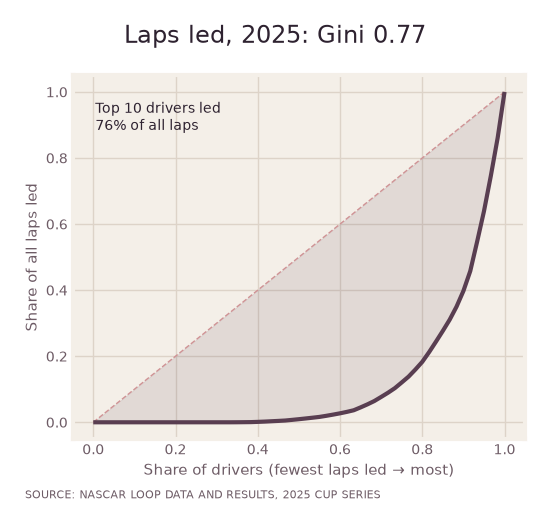

In [4]:
by_driver = s.groupby("driver").lead_laps.sum().sort_values()
cum = np.insert(by_driver.cumsum().values / by_driver.sum(), 0, 0)
x = np.linspace(0, 1, len(cum))
gini = 1 - 2 * np.trapezoid(cum, x)
fig, ax = plt.subplots(figsize=(5.2, 4.6))
ax.plot([0, 1], [0, 1], color=CONTEXT, lw=1, ls="--")
ax.plot(x, cum, color=FIELD)
ax.fill_between(x, cum, x, color=FIELD, alpha=0.12)
top10 = by_driver.sort_values(ascending=False).head(10).sum() / by_driver.sum()
ax.set_xlabel("Share of drivers (fewest laps led → most)"); ax.set_ylabel("Share of all laps led")
headline(fig, f"Laps led, 2025: Gini {gini:.2f}")
ax.text(0.05, 0.85, f"Top 10 drivers led\n{top10:.0%} of all laps", color=INK, fontsize=10, transform=ax.transAxes)
source(fig); plt.show()

## Who leads, and where

Laps led by team and track type. Each column sums to 100%: the share of all laps led at that kind of track. The same few organizations dominate everywhere except superspeedways, where pack racing spreads the lead around.

/var/folders/0f/9rvn96j94zsfhr8zsbzjx1700000gn/T/ipykernel_85728/801213864.py:5: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  tbl = tbl.loc[list(tbl.drop("All other teams").sum(1).sort_values(ascending=False).index) + ["All other teams"]]


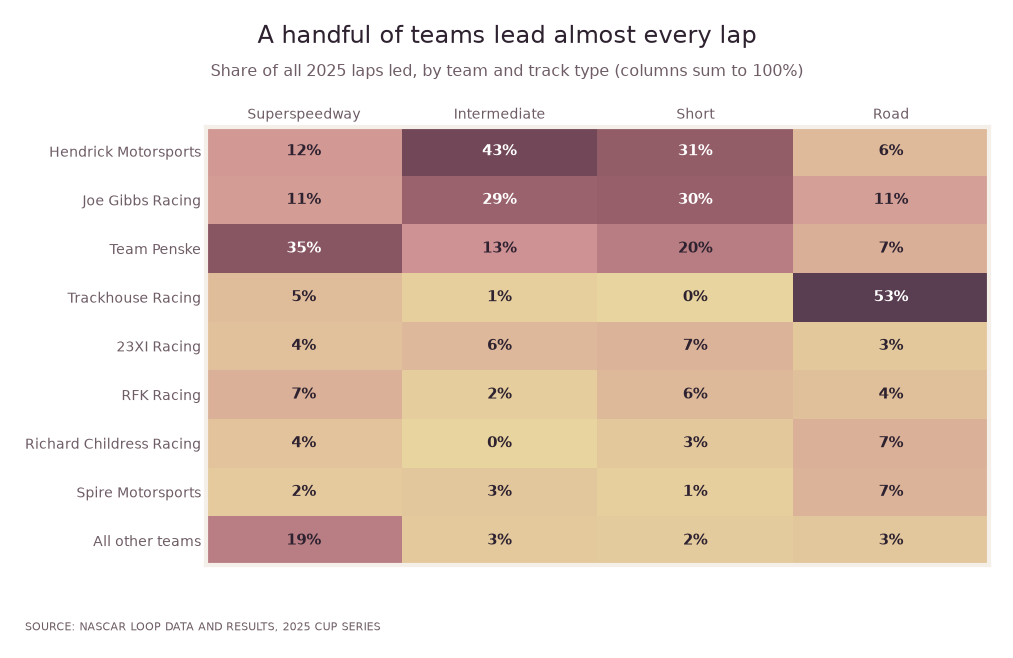

In [5]:
s["track_type"] = s.track_type.str.title()
top_teams = s.groupby("team_name").lead_laps.sum().nlargest(8).index
tbl = s.assign(team=np.where(s.team_name.isin(top_teams), s.team_name, "All other teams")).pivot_table(index="team", columns="track_type", values="lead_laps", aggfunc="sum").fillna(0)
tbl = (tbl / tbl.sum() * 100)[["Superspeedway", "Intermediate", "Short", "Road"]]
tbl = tbl.loc[list(tbl.drop("All other teams").sum(1).sort_values(ascending=False).index) + ["All other teams"]]
fig, ax = plt.subplots(figsize=(9, 6))
im = ax.imshow(tbl.values, cmap=SEQ, aspect="auto", vmin=0, vmax=tbl.values.max())
for i in range(tbl.shape[0]):
    for j in range(tbl.shape[1]):
        v = tbl.values[i, j]; ax.text(j, i, f"{v:.0f}%", ha="center", va="center", fontsize=11, fontweight="bold", color="white" if v > tbl.values.max() * 0.55 else INK)
ax.set_xticks(range(4), tbl.columns); ax.set_yticks(range(len(tbl)), tbl.index); ax.grid(False)
ax.tick_params(axis="x", top=True, bottom=False, labeltop=True, labelbottom=False)
headline(fig, "A handful of teams lead almost every lap", "Share of all 2025 laps led, by team and track type (columns sum to 100%)")
source(fig); plt.show()

## Running position and finish are related, but not the same

A car can run 10th all day and crash on the last lap, or run 30th and inherit a top-15 finish. Camera time follows where the car *runs*, so the model uses average running position, not finish.

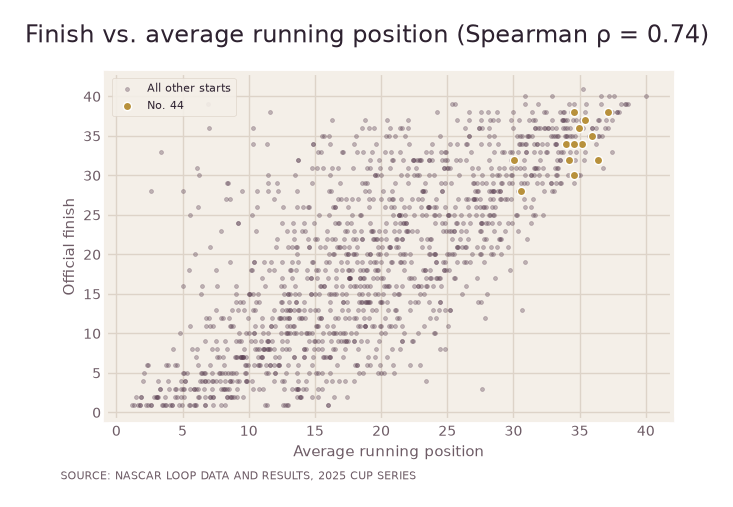

In [6]:
fig, ax = plt.subplots(figsize=(6.5, 4.4))
other = s[~s.is_ny_racing]
ax.scatter(other.avg_ps, other.finish, s=8, color=FIELD, alpha=0.35, label="All other starts")
ax.scatter(ny.avg_ps, ny.finish, s=36, color=NY, edgecolor="white", linewidth=1, label="No. 44", zorder=3)
ax.set_xlabel("Average running position"); ax.set_ylabel("Official finish")
r = s[["avg_ps", "finish"]].corr(method="spearman").iloc[0, 1]
headline(fig, f"Finish vs. average running position (Spearman ρ = {r:.2f})")
ax.legend(fontsize=8, loc="upper left")
source(fig); plt.show()

## Takeaways for the model

- The No. 44's median average running position is about 35th, near the back of every field.
- A small group of drivers leads almost all laps, so a leader-following share of camera time will go to very few cars.
- Average running position is the right driver of camera time, since finish adds noise from late incidents and penalties.

**Next:** [03 · Exposure model](03_exposure_model.ipynb)